## Задача 1

**Nursing    Home    Data**

Описание переменных
- BED = число коек в больнице
- MCDAYS = annual medical in-patient days (hundreds)
- TDAYS = annual total patient days (hundreds)
- PCREV = получено от пациентов за год (в сотнях долларов)
- NSAL = годовой оклад медсестры (в сотнях долларов)
- FEXP = расходы больницы за год (сотни долларов)
- RURAL = код типа больницы: загородная (код 1) или городская (код 0)  



Сравнить показатели для больниц расположенных за городом и в городе.

Расходы больницы за год (сотни долларов)

### Решение

**Постановка задачи и гипотезы**

Необходимо проверить, существуют ли статистически значимые различия в годовых расходах между загородными и городскими больницами.

Нулевая гипотеза $H_0$: Средние годовые расходы в загородных и городских больницах не различаются.

Альтернативная гипотеза $H_1$: Средние годовые расходы в загородных и городских больницах статистически значимо различаются.

Подгружаем данные и проверяем на нормальность:

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv('/content/Nursing Home Data_data', sep=';')
df.head()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
0,244,128,385,23521,5230,5334,0
1,59,155,203,9160,2459,493,1
2,120,281,392,21900,6304,6115,0
3,120,291,419,22354,6590,6346,0
4,120,238,363,17421,5362,6225,0


In [9]:
rural_expenses = df[df['RURAL'] == 1]['FEXP']
urban_expenses = df[df['RURAL'] == 0]['FEXP']

In [38]:
def two_hist (x, y):
  x.hist(alpha=0.5, weights=[1./len(x)]*len(x))
  y.hist(alpha=0.5, weights=[1./len(y)]*len(y))
  plt.axvline(x.mean(), color='red', alpha=0.8, linestyle='dashed')
  plt.axvline(y.mean(), color='blue', alpha=0.8, linestyle='dashed')
  plt.legend([x.name, y.name])

In [46]:
rural_expenses.name = 'За городом'
urban_expenses.name = 'В городе'

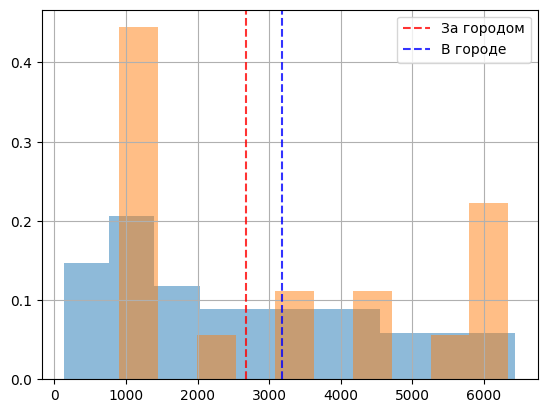

In [47]:
two_hist(rural_expenses, urban_expenses)

In [16]:
shapiro_rural = stats.shapiro(rural_expenses)
print('Для загородных больниц p-value: ', shapiro_rural[1])

shapiro_urban = stats.shapiro(urban_expenses)
print('Для городских больниц p-value: ', shapiro_urban[1])

Для загородных больниц p-value:  0.04017793201644618
Для городских больниц p-value:  0.003969292378007504


В обоих случаях значение p-value меньше 0.05, то есть распеределения не являются нормальными (по гистограмме это тоже можно увидеть).

Следовательно, мы проверяем гипотезу о равенстве медиан через критерий Манна-Уитни.

In [20]:
u_statistic, p_value = stats.mannwhitneyu(rural_expenses, urban_expenses, alternative='two-sided')
print(f"Медиана расходов в городских больницах: {urban_expenses.median()}")
print(f"Медиана расходов в загородных больницах: {rural_expenses.median()}")
print(f"U-критерий Манна-Уитни: U-статистика = {u_statistic}, p-значение = {p_value:.4f}")

Медиана расходов в городских больницах: 2737.0
Медиана расходов в загородных больницах: 2377.5
U-критерий Манна-Уитни: U-статистика = 273.0, p-значение = 0.5319


p-значение больше 0.05 => Принимаем нулевую гипотезу. Статистически значимых различий в расходах не обнаружено. То есть расходы в городских и загородных больницах сильно не различаются.


#### Посмотрим на ящики с усами:

/tmp/ipykernel_415/4264188044.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, patch_artist=True, labels=['Городские (RURAL=0)', 'Загородные (RURAL=1)'],


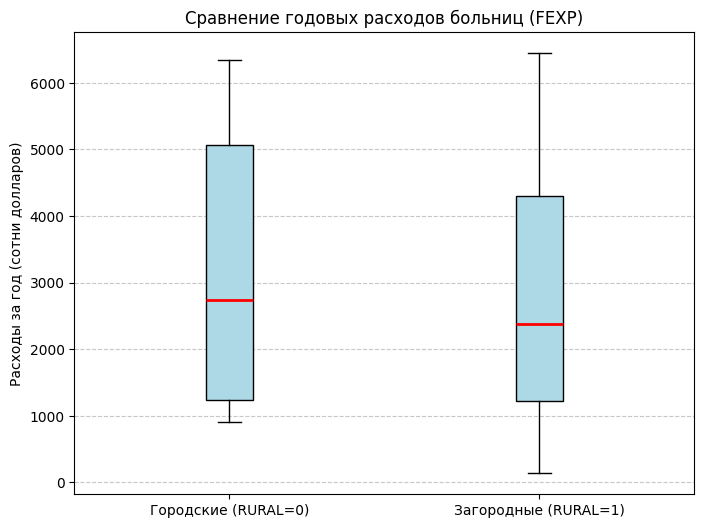

In [24]:
plt.figure(figsize=(8, 6))

data_to_plot = [urban_expenses, rural_expenses]

bp = plt.boxplot(data_to_plot, patch_artist=True, labels=['Городские (RURAL=0)', 'Загородные (RURAL=1)'],
                 boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))

plt.title('Сравнение годовых расходов больниц (FEXP)')
plt.ylabel('Расходы за год (сотни долларов)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Красная линия внутри каждого ящика — медиана.

Границы ящика — первый (Q1) и третий (Q3) квартили.

Усы показывают разброс данных за пределами ящика (обычно до 1.5*IQR).

На графике видно, что медиана городских больниц немного выше, но разброс данных (ящики) сильно перекрываются, что объясняет, почему p-value > 0.05 и различия не являются статистически значимыми.

## Задача 2

**Unions and State Labor Law**

Variable Names:
- DENS: 	Percent of public sector employees in unions, 1982
- COMP: 	State bargaining laws cover public employees (1) or not (0)
- RTW: 	State right-to-work law (1) or not (0)
- PVT: 	Percent of private sector employees in unions, 1982

Сравнить процент муниципальных служащих, состоящих в профсоюзах в 1982 в разных штатах США. Сравниваются штаты, отличающиеся по тому, принят ли в этих штатах соответствующий закон (код 1) или не принят (код 0)


Сравниваются штаты, в которых принят закон  State right-to-work law и те, в которых закон не принят.

### Решение

**Постановка задачи и гипотезы**

Проверить, влияет ли наличие закона "right-to-work" на процент муниципальных служащих, состоящих в профсоюзах.

Нулевая гипотеза ($H_0$): Нет различий в проценте членов профсоюзов между штатами с законом и без него.

Т.е. Закон "right-to-work" никак не влияет на желание муниципальных служащих вступать в профсоюзы. Процент "профсоюзников" примерно одинаковый в штатах с законом и без него.

Альтернативная гипотеза ($H_1$): Различия в проценте членов профсоюзов между группами статистически значимы.

Т.е. Закон "right-to-work" влияет на желание муниципальных служащих вступать в профсоюзы.

Проверка на нормальность:

In [28]:
df = pd.read_csv('/content/Unions and State Labor Law_data', sep = '\t')
df.head()

,STATE,DENS,COMP,RTW,PVT
0,NY,56.9,1,0,31.2
1,MI,49.6,1,0,30.2
2,WA,32.4,1,0,33.1
3,HI,54.6,1,0,24.7
4,AK,30.7,1,0,30.1


In [29]:
rtw_0 = df[df['RTW'] == 0]['DENS']
rtw_1 = df[df['RTW'] == 1]['DENS']

In [48]:
rtw_0.name = 'Без закона'
rtw_1.name = 'С законом'

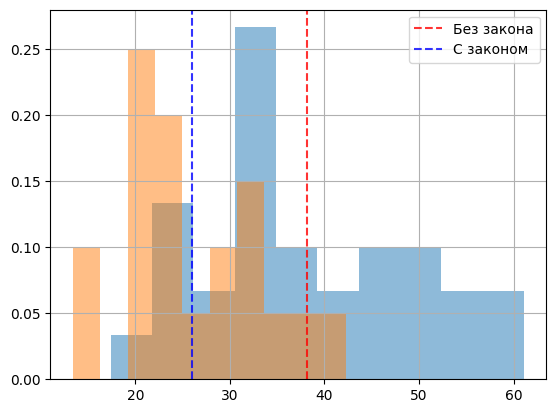

In [49]:
two_hist(rtw_0, rtw_1)

In [30]:
shapiro_0 = stats.shapiro(rtw_0)
print('Для штатов без закона p-value: ', shapiro_0[1])

shapiro_1 = stats.shapiro(rtw_1)
print('Для штатов с законом p-value: ', shapiro_1[1])

Для штатов без закона p-value:  0.19172901843820855
Для штатов с законом p-value:  0.646398255132793


В обоих случаях значение p-value больше 0.05, то есть распеределения являются близкими к нормальныму.

Следовательно, дальше надо проверить равны ли дисперсии:

In [31]:
disp_res = stats.fligner(rtw_0, rtw_1)
print('p-value: ', disp_res[1])

p-value:  0.12569758439648204


p-value больше уровня значимости 0.05 => принимаем гипотезу о равенстве дисперсий.

В этих выборках находятся независимые объекты, поэтому гипотезу о равенстве средних проверяем через критерий Стьюдента для независимых выборок.

In [33]:
res = stats.ttest_ind(rtw_0, rtw_1, equal_var=True)
print('p-value: ', res[1])

p-value:  9.287017631717846e-05


Значение p-value меньше 0.05, следовательно мы отвергаем нулевую гипотезу. Различия в проценте членов профсоюзов между группами статистически значимы, а значит закон влияет на желание служащих вступать в профсоюзы.

/tmp/ipykernel_415/3571212711.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['RTW'] == 0]['DENS'], df[df['RTW'] == 1]['DENS']],


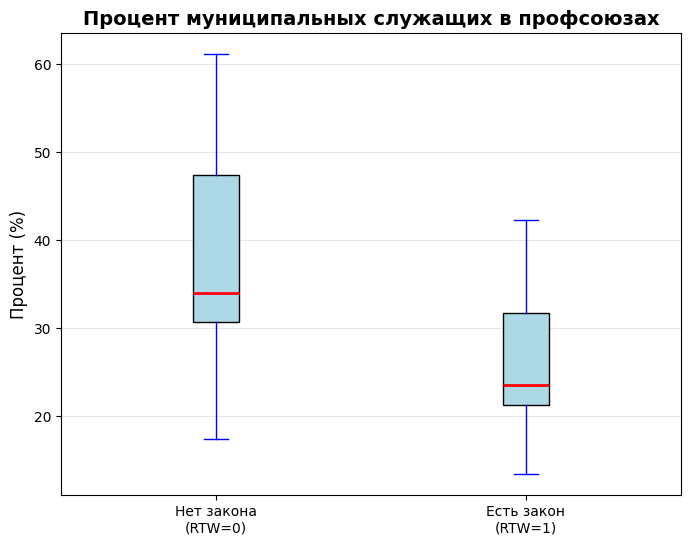

In [36]:
plt.figure(figsize=(8, 6))

plt.boxplot([df[df['RTW'] == 0]['DENS'], df[df['RTW'] == 1]['DENS']],
            labels=['Нет закона\n(RTW=0)', 'Есть закон\n(RTW=1)'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'))

plt.title('Процент муниципальных служащих в профсоюзах', fontsize=14, fontweight='bold')
plt.ylabel('Процент (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

В штатах, где принят этот закон (разрешающий работать без вступления в профсоюз), процент муниципальных служащих в профсоюзах систематически ниже. Это соответствует логике: когда у работников есть выбор не вступать в профсоюз и не платить взносы, многие этим пользуются.

Разница настолько заметна, что ящики даже не перекрываются своими средними частями — бóльшая часть штатов без закона имеет более высокие показатели, чем бóльшая часть штатов с законом.